# Autoresearch: CLD2 Language Detection Speed Optimization

Analysis of autonomous optimization experiments on CLD2. Goal: minimize `total_ms` while maintaining prediction `accuracy` at 1.0.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results.tsv", sep="\t")
df["total_ms"] = pd.to_numeric(df["total_ms"], errors="coerce")
df["accuracy"] = pd.to_numeric(df["accuracy"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 28
Columns: ['commit', 'total_ms', 'accuracy', 'status', 'description']


,commit,total_ms,accuracy,status,description
0,73b2d27,3564.877,1.0,KEEP,baseline
1,143d9de,3508.268,1.0,KEEP,stack-allocate ScoringHitBuffer and predict_tbl
2,40e2605,3404.265,1.0,KEEP,disable OffsetMap tracking when resultchunkvec...
3,f01af5e,3370.533,1.0,KEEP,skip LowerScriptSpan for caseless scripts
4,bd25c93,3303.989,1.0,KEEP,reduce lang tag scan from 8KB to 1KB
5,cc3555e,3528.921,1.0,DISCARD,disable forced word scoring (slower)
6,5d03004,0.000,0.0,CRASH,skip UTF-8 validation (segfaults)
7,f15f58b,3317.393,1.0,KEEP,stack-allocate close_set_count
8,8df094b,3272.997,1.0,KEEP,fast ASCII path in GetUTF8LetterScriptNum
9,282b76d,3256.943,1.0,KEEP,fast ASCII scan in ScanToLetterOrSpecial


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")
    print(f"Crashes: {n_crash}")

Experiment outcomes:
status
KEEP       22
DISCARD     5
CRASH       1

Keep rate: 22/27 = 81.5%
Crashes: 1


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    ms = row["total_ms"]
    acc = row["accuracy"]
    desc = row["description"]
    print(f"  #{i:3d}  {ms:8.1f}ms  acc={acc:.4f}  {desc}")

KEPT experiments (22 total):

  #  0    3564.9ms  acc=1.0000  baseline
  #  1    3508.3ms  acc=1.0000  stack-allocate ScoringHitBuffer and predict_tbl
  #  2    3404.3ms  acc=1.0000  disable OffsetMap tracking when resultchunkvector is NULL
  #  3    3370.5ms  acc=1.0000  skip LowerScriptSpan for caseless scripts
  #  4    3304.0ms  acc=1.0000  reduce lang tag scan from 8KB to 1KB
  #  7    3317.4ms  acc=1.0000  stack-allocate close_set_count
  #  8    3273.0ms  acc=1.0000  fast ASCII path in GetUTF8LetterScriptNum
  #  9    3256.9ms  acc=1.0000  fast ASCII scan in ScanToLetterOrSpecial
  # 10    3133.9ms  acc=1.0000  early exit at 112KB text limit
  # 12    3140.5ms  acc=1.0000  OffsetMap::Clear no-op when inactive
  # 13    3122.3ms  acc=1.0000  fast ASCII lowercase in LowerScriptSpan
  # 14    3103.2ms  acc=1.0000  batch-copy ASCII Latin letters in inner loop
  # 15    3096.4ms  acc=1.0000  reduce smoothwidth from 20 to 10
  # 16    3086.1ms  acc=1.0000  cap ScriptScanner view to 13

## Prediction Time Over Experiments

Track how `total_ms` evolves as experiments progress. The running minimum shows the frontier -- the fastest result achieved so far. Discarded experiments (accuracy loss or slower) are shown in gray.

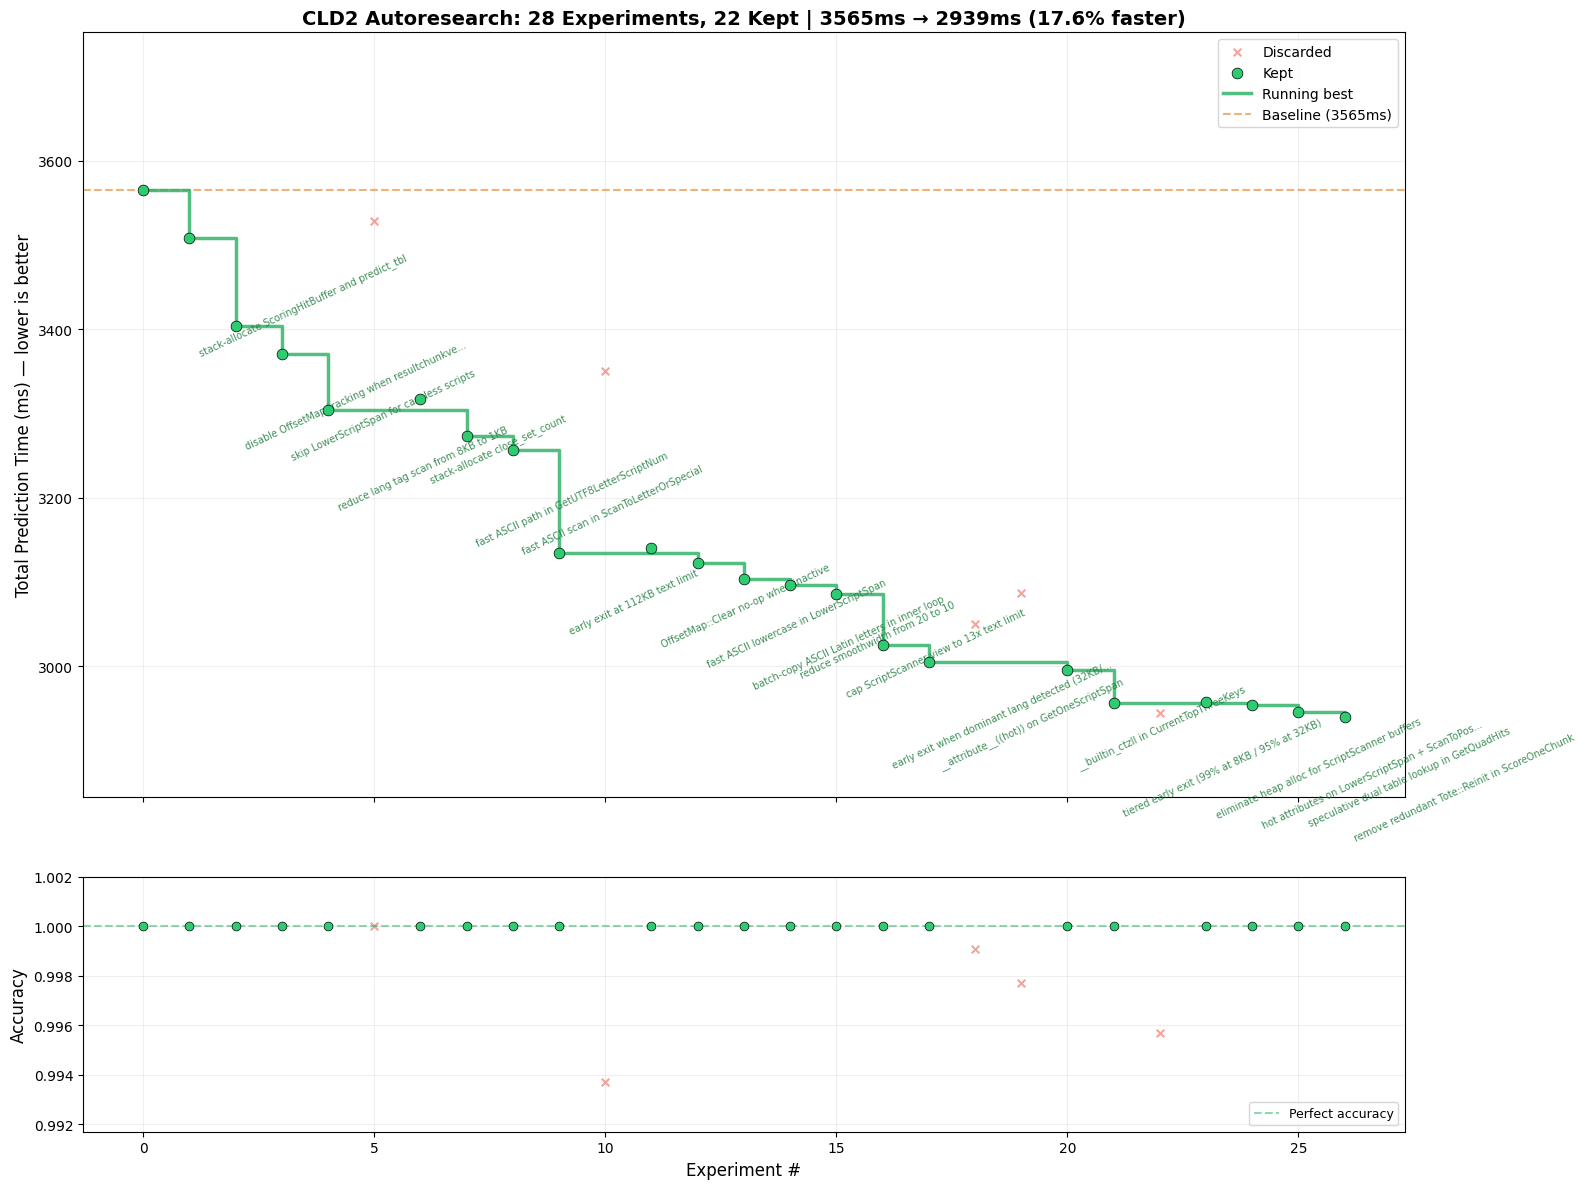

Saved to progress.png


In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), height_ratios=[3, 1], sharex=True)

# Filter out crashes for the main plot
valid = df[df["status"] != "CRASH"].copy().reset_index(drop=True)
baseline_ms = valid.loc[0, "total_ms"]

# ── Top panel: total_ms over time ──
# Discarded as faint red dots
disc = valid[valid["status"] == "DISCARD"]
ax1.scatter(disc.index, disc["total_ms"],
           c="#e74c3c", s=30, alpha=0.5, zorder=2, label="Discarded", marker="x")

# Kept experiments as prominent green dots
kept_v = valid[valid["status"] == "KEEP"]
ax1.scatter(kept_v.index, kept_v["total_ms"],
           c="#2ecc71", s=60, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_ms = valid.loc[kept_mask, "total_ms"]
running_min = kept_ms.cummin()
ax1.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2.5, alpha=0.8, zorder=3, label="Running best")

# Baseline reference line
ax1.axhline(y=baseline_ms, color="#e67e22", linewidth=1.5, linestyle="--",
           alpha=0.6, label=f"Baseline ({baseline_ms:.0f}ms)")

# Label each kept experiment with its description
for idx, ms_val in zip(kept_idx, kept_ms):
    if ms_val >= baseline_ms:
        continue  # skip baseline label
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 48:
        desc = desc[:45] + "..."
    ax1.annotate(desc, (idx, ms_val),
                textcoords="offset points",
                xytext=(6, -10), fontsize=7.0,
                color="#1a7a3a", alpha=0.85,
                rotation=25, ha="left", va="top")

best_ms = kept_ms.min()
n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
speedup_pct = (baseline_ms - best_ms) / baseline_ms * 100

ax1.set_ylabel("Total Prediction Time (ms) — lower is better", fontsize=12)
ax1.set_title(
    f"CLD2 Autoresearch: {n_total} Experiments, {n_kept} Kept | "
    f"{baseline_ms:.0f}ms → {best_ms:.0f}ms ({speedup_pct:.1f}% faster)",
    fontsize=14, fontweight="bold")
ax1.legend(loc="upper right", fontsize=10)
ax1.grid(True, alpha=0.2)

margin = (baseline_ms - best_ms) * 0.15
ax1.set_ylim(best_ms - margin, baseline_ms + margin * 2)

# ── Bottom panel: accuracy ──
all_valid_acc = valid["accuracy"]
ax2.scatter(disc.index, disc["accuracy"],
           c="#e74c3c", s=30, alpha=0.5, zorder=2, marker="x")
ax2.scatter(kept_v.index, kept_v["accuracy"],
           c="#2ecc71", s=40, zorder=4, edgecolors="black", linewidths=0.5)
ax2.axhline(y=1.0, color="#27ae60", linewidth=1.5, linestyle="--", alpha=0.5, label="Perfect accuracy")
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.set_xlabel("Experiment #", fontsize=12)
ax2.set_ylim(min(all_valid_acc.min() - 0.002, 0.992), 1.002)
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
kept = df[df["status"] == "KEEP"].copy()
baseline_ms = df.iloc[0]["total_ms"]
best_ms = kept["total_ms"].min()
best_row = kept.loc[kept["total_ms"].idxmin()]

print(f"Baseline total_ms:  {baseline_ms:.3f}")
print(f"Best total_ms:      {best_ms:.3f}")
print(f"Time saved:         {baseline_ms - best_ms:.3f}ms ({(baseline_ms - best_ms) / baseline_ms * 100:.1f}%)")
print(f"Accuracy:           {best_row['accuracy']:.4f}")
print(f"Best experiment:    {best_row['description']}")
print()

print("Progression of kept improvements:")
for i, (_, row) in enumerate(kept.iterrows()):
    desc = str(row["description"]).strip()
    pct = (baseline_ms - row["total_ms"]) / baseline_ms * 100
    marker = " <-- best" if row["total_ms"] == best_ms else ""
    print(f"  #{i:2d}  {row['total_ms']:8.1f}ms  ({pct:+5.1f}%)  {desc}{marker}")

Baseline total_ms:  3564.877
Best total_ms:      2938.938
Time saved:         625.939ms (17.6%)
Accuracy:           1.0000
Best experiment:    remove redundant Tote::Reinit in ScoreOneChunk

Progression of kept improvements:
  # 0    3564.9ms  ( +0.0%)  baseline
  # 1    3508.3ms  ( +1.6%)  stack-allocate ScoringHitBuffer and predict_tbl
  # 2    3404.3ms  ( +4.5%)  disable OffsetMap tracking when resultchunkvector is NULL
  # 3    3370.5ms  ( +5.5%)  skip LowerScriptSpan for caseless scripts
  # 4    3304.0ms  ( +7.3%)  reduce lang tag scan from 8KB to 1KB
  # 5    3317.4ms  ( +6.9%)  stack-allocate close_set_count
  # 6    3273.0ms  ( +8.2%)  fast ASCII path in GetUTF8LetterScriptNum
  # 7    3256.9ms  ( +8.6%)  fast ASCII scan in ScanToLetterOrSpecial
  # 8    3133.9ms  (+12.1%)  early exit at 112KB text limit
  # 9    3140.5ms  (+11.9%)  OffsetMap::Clear no-op when inactive
  #10    3122.3ms  (+12.4%)  fast ASCII lowercase in LowerScriptSpan
  #11    3103.2ms  (+12.9%)  batch-copy 

## Top Hits (Ranked by Improvement)

In [6]:
# Each kept experiment's delta vs the previous kept experiment
kept = df[df["status"] == "KEEP"].copy()
kept["prev_ms"] = kept["total_ms"].shift(1)
kept["delta_ms"] = kept["prev_ms"] - kept["total_ms"]  # positive = improvement

hits = kept.iloc[1:].copy()  # drop baseline
hits = hits.sort_values("delta_ms", ascending=False)

print(f"{'Rank':>4}  {'Saved':>9}  {'total_ms':>10}  Description")
print("-" * 90)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta_ms']:+8.1f}ms  {row['total_ms']:9.1f}ms  {row['description']}")

total_saved = kept.iloc[0]["total_ms"] - kept.iloc[-1]["total_ms"]
print(f"\n{'':>4}  {total_saved:+8.1f}ms  {'':>10}  TOTAL saved vs baseline")

Rank      Saved    total_ms  Description
------------------------------------------------------------------------------------------
   1    +123.1ms     3133.9ms  early exit at 112KB text limit
   2    +104.0ms     3404.3ms  disable OffsetMap tracking when resultchunkvector is NULL
   3     +66.5ms     3304.0ms  reduce lang tag scan from 8KB to 1KB
   4     +61.3ms     3024.9ms  early exit when dominant lang detected (32KB/95%)
   5     +56.6ms     3508.3ms  stack-allocate ScoringHitBuffer and predict_tbl
   6     +44.4ms     3273.0ms  fast ASCII path in GetUTF8LetterScriptNum
   7     +40.1ms     2955.6ms  tiered early exit (99% at 8KB / 95% at 32KB)
   8     +33.7ms     3370.5ms  skip LowerScriptSpan for caseless scripts
   9     +19.7ms     3005.2ms  __attribute__((hot)) on GetOneScriptSpan
  10     +19.1ms     3103.2ms  batch-copy ASCII Latin letters in inner loop
  11     +18.1ms     3122.3ms  fast ASCII lowercase in LowerScriptSpan
  12     +16.1ms     3256.9ms  fast ASCII scan i

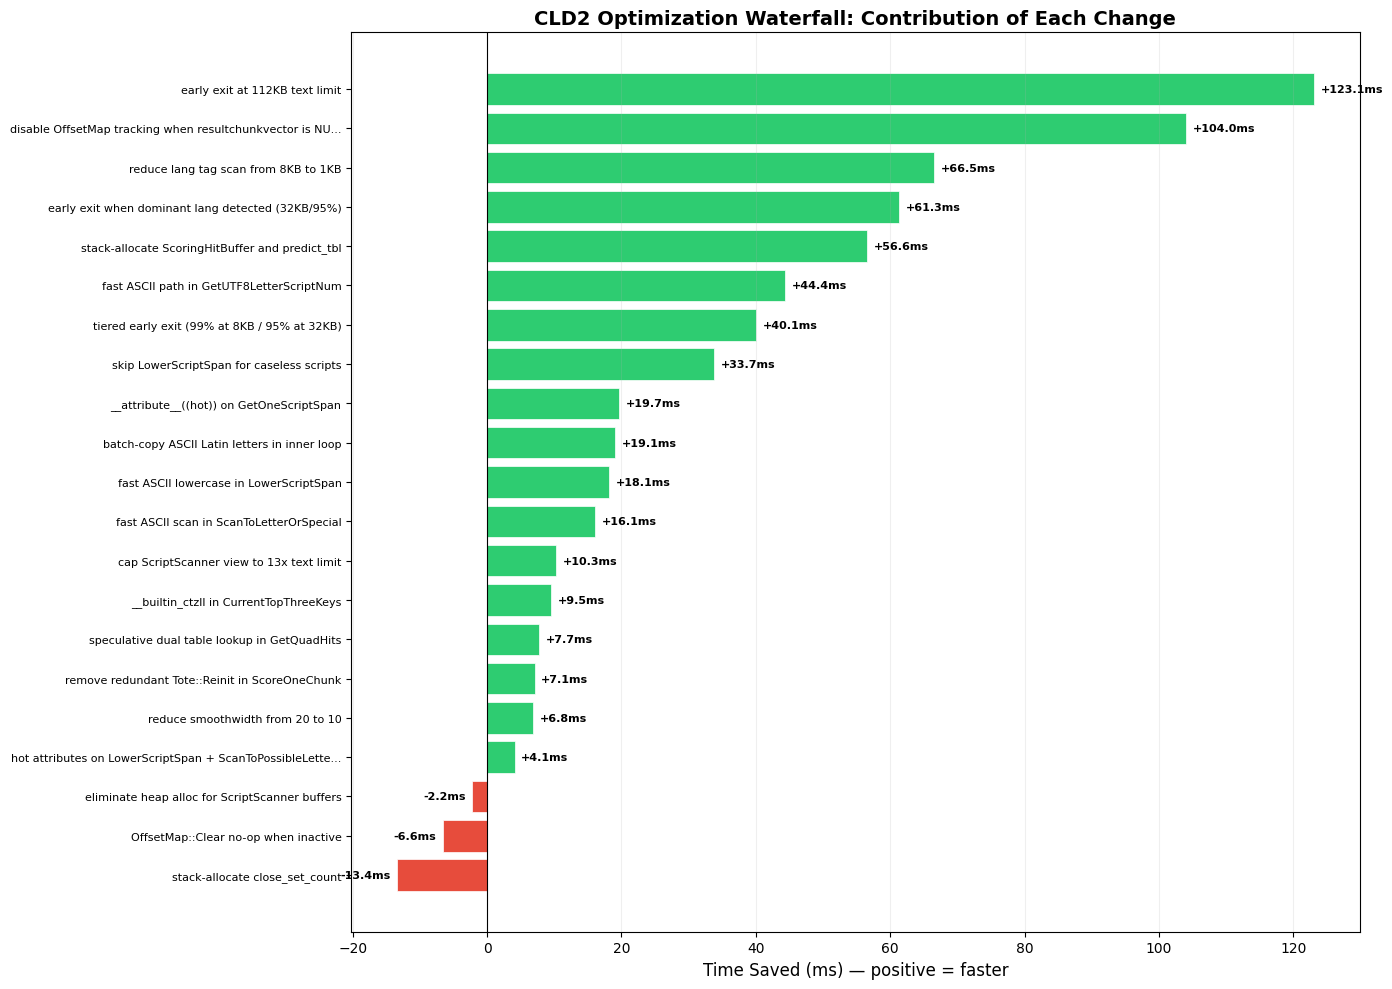

Saved to waterfall.png


In [7]:
# Waterfall chart: contribution of each optimization
kept = df[df["status"] == "KEEP"].copy()
kept["prev_ms"] = kept["total_ms"].shift(1)
kept["delta_ms"] = kept["prev_ms"] - kept["total_ms"]
hits = kept.iloc[1:].copy().sort_values("delta_ms", ascending=True)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(14, 10))

# Truncate descriptions for readability
labels = [d[:55] + "..." if len(d) > 55 else d for d in hits["description"]]
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in hits["delta_ms"]]

bars = ax.barh(range(len(hits)), hits["delta_ms"], color=colors, edgecolor="white", linewidth=0.5)

# Add value labels
for i, (val, bar) in enumerate(zip(hits["delta_ms"], bars)):
    x_pos = val + 1 if val > 0 else val - 1
    ha = "left" if val > 0 else "right"
    ax.text(x_pos, i, f"{val:+.1f}ms", va="center", ha=ha, fontsize=8, fontweight="bold")

ax.set_yticks(range(len(hits)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Time Saved (ms) — positive = faster", fontsize=12)
ax.set_title("CLD2 Optimization Waterfall: Contribution of Each Change", fontsize=14, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.grid(True, axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to waterfall.png")